**Aggregation Model**

In [1]:
## DATA AND PACKAGE IMPORT 

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from types import SimpleNamespace

## import data from particle concentration, backscatter, fluorescence
part_conc_490 = pd.read_excel("UVP_Float_Data.xlsx", sheet_name="4903659_binned_small_removed").iloc[:, 1:]
part_conc_699 = pd.read_excel("UVP_Float_Data.xlsx", sheet_name="6990636_binned_small_removed").iloc[:, 1:]

bbp_490 = pd.read_excel("BBP_binned.xlsx", sheet_name="4903659")
bbp_699 = pd.read_excel("BBP_binned.xlsx", sheet_name="6990636")

chla_fluor_490 = pd.read_excel("Chl_fluor_binned.xlsx", sheet_name="4903659")
chla_fluor_699 = pd.read_excel("Chl_fluor_binned.xlsx", sheet_name="6990636")

# define depth array, time array (profiles)
depth = part_conc_490["depth_bin"].iloc[:60]
time_490 = pd.Series(range(1, 45))
time_699 = pd.Series(range(1, 78))            # probably won't use all of these profiles
#size_classes = part_conc_490.columns.to_numpy()[1:]
sizes = np.array([102,128,161,203,256,323,406,512,645,813,1020,1290,1630,2050,2580])

In [2]:
## SEPARATING FLOAT 490 PROFILES INTO INDIVIDUAL UVP6 DATAFRAMES 
# this does not contain backscatter or fluorescence yet

# Create container object
f490 = SimpleNamespace()

# Identify blank rows (all NaN) and get indices
blank_rows = part_conc_490.isna().all(axis=1)
split_points = blank_rows[blank_rows].index.tolist()

# Add start and end boundaries
split_points = [-1] + split_points + [len(part_conc_490)]

skip_numbers = {13, 19}

section_number = 1

for i in range(len(split_points) - 1):
    start = split_points[i] + 1
    end = split_points[i + 1]

    # Extract the block
    block = part_conc_490.iloc[start:end].reset_index(drop=True)

    #block["bbp"] = bbp_490.iloc[:len(block), section_number - 1].values
    #block["chla"] = chla_fluor_490.iloc[:len(block), section_number - 1].values

# Skip truly empty blocks
    if len(block) == 0:
        continue
    
# Skip numbers before assigning
    while section_number in skip_numbers:
        section_number += 1

    attr_name = f"p{section_number}"
    setattr(f490, attr_name, block)

    section_number += 1

# Export an individual profile here (in case one needs checking!)
#f490.p7.to_excel("f490.p7.xlsx", index=False)




## tada, doing the same with 6990636 
# this does not contain backscatter or fluorescence yet

# Create container object
f699 = SimpleNamespace()

# Identify blank rows (all NaN) and get indices
blank_rows = part_conc_699.isna().all(axis=1)
split_points = blank_rows[blank_rows].index.tolist()

# Add start and end boundaries
split_points = [-1] + split_points + [len(part_conc_699)]

skip_numbers = {4, 17, 29, 53, 72}   # works too 11/6

section_number = 1

for i in range(len(split_points) - 1):
    start = split_points[i] + 1
    end = split_points[i + 1]

    # Extract the block
    block = part_conc_699.iloc[start:end].reset_index(drop=True)

    #block["bbp"] = bbp_490.iloc[:len(block), section_number - 1].values
    #block["chla"] = chla_fluor_490.iloc[:len(block), section_number - 1].values

# Skip truly empty blocks
    if len(block) == 0:
        continue
    
# Skip numbers before assigning
    while section_number in skip_numbers:
        section_number += 1

    attr_name = f"p{section_number}"
    setattr(f699, attr_name, block)

    section_number += 1

# Export an individual profile here (in case one needs checking!)
# f699.p8.to_excel("f699.p8.xlsx", index=False)


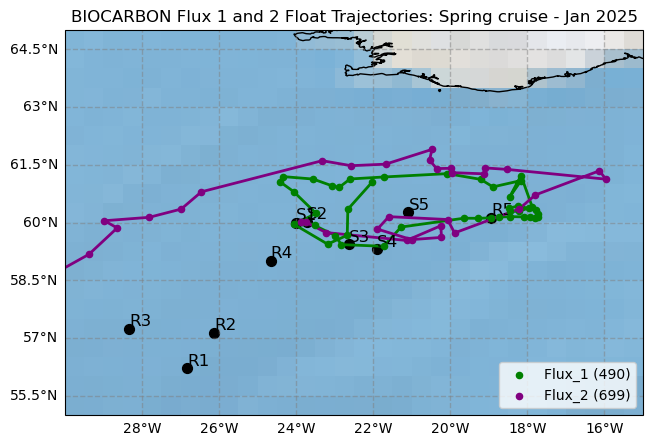

'"\n# Plotting particle concentration data with time\nfig, ax = plt.subplots()\n\n# Particle size 102 data for 490\n# time = (float numbers/dates)\n# y = (data from all profiles for f490)\n\n# Create figure and axes\nfig, ax = plt.subplots()\n\n# Plot the data\nax.plot(x, y, marker=\'o\')\nax.set_xlabel("X values")\nax.set_ylabel("Y values")\nax.set_title("Simple Line Plot")\nax.grid(True)\nplt.show()\n\n'

In [21]:
## Creating Figures for Presentation

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Argo float trajectories figure

float_data = pd.read_excel("UVP_Float_Data.xlsx", sheet_name="UVP_Float_Data")
lat = float_data.loc[:,"latitude"]
lon = float_data.loc[:,"longitude"]
lat.drop_duplicates(inplace = True), lon.drop_duplicates(inplace = True)

# index of first value of 699 is 44
lat_490 = lat[:44]
lon_490 = lon[:44]
lat_699 = lat[44:]
lon_699 = lon[44:]

# plotting on map

# Create a figure with a map projection
fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.OCEAN) #facecolor='lightblue')
ax.stock_img()

gl = ax.gridlines(draw_labels=True,
                  linewidth=1,
                  color='gray',
                  alpha=0.5,
                  linestyle='--')

gl.top_labels = False
gl.right_labels = False

s1_lat = 60.00016
s1_lon = -24.0004
s2_lat = 60.01922
s2_lon = -23.7194 
s3_lat = 59.43715
s3_lon = -22.6379 
s4_lat = 59.30469
s4_lon = -21.9108 
s5_lat = 60.26593
s5_lon = -21.0875

r1_lat = 56.21604
r1_lon = -26.8302
r2_lat = 57.12564
r2_lon = -26.1376
r3_lat = 57.23220
r3_lon = -28.3443
r4_lat = 59.01343
r4_lon = -24.6674 
r5_lat = 60.12009
r5_lon = -18.9309


# Plot the points
ax.scatter(lon_490, lat_490, color='green', s=20, label="Flux_1 (490)", transform=ccrs.PlateCarree(), zorder=5)
ax.scatter(lon_699, lat_699, color='purple', s=20, label="Flux_2 (699)", transform=ccrs.PlateCarree(), zorder=5)

ax.legend(loc='lower right')

ax.scatter(s1_lon, s1_lat, color='black', s=50, label="S1", transform=ccrs.PlateCarree())
ax.scatter(s2_lon, s2_lat, color='black', s=50, label="S2", transform=ccrs.PlateCarree())
ax.scatter(s3_lon, s3_lat, color='black', s=50, label="S3", transform=ccrs.PlateCarree())
ax.scatter(s4_lon, s4_lat, color='black', s=50, label="S4", transform=ccrs.PlateCarree())
ax.scatter(s5_lon, s5_lat, color='black', s=50, label="S5", transform=ccrs.PlateCarree())

ax.scatter(r1_lon, r1_lat, color='black', s=50, label="R1", transform=ccrs.PlateCarree())
ax.scatter(r2_lon, r2_lat, color='black', s=50, label="R2", transform=ccrs.PlateCarree())
ax.scatter(r3_lon, r3_lat, color='black', s=50, label="R3", transform=ccrs.PlateCarree())
ax.scatter(r4_lon, r4_lat, color='black', s=50, label="R4", transform=ccrs.PlateCarree())
ax.scatter(r5_lon, r5_lat, color='black', s=50, label="R5", transform=ccrs.PlateCarree())


# Draw lines connecting points
ax.plot(lon_490, lat_490, color='green', linewidth=2, transform=ccrs.PlateCarree())
ax.plot(lon_699, lat_699, color='purple', linewidth=2, transform=ccrs.PlateCarree())

# Set extent (optional: zoom to data)
ax.set_extent([
    -30, -15,
    55, 65
])

ax.text(s1_lon, s1_lat, "S1", fontsize=12, ha='left', va='bottom')
ax.text(s2_lon, s2_lat, "S2", fontsize=12, ha='left', va='bottom')
ax.text(s3_lon, s3_lat, "S3", fontsize=12, ha='left', va='bottom')
ax.text(s4_lon, s4_lat, "S4", fontsize=12, ha='left', va='bottom')
ax.text(s5_lon, s5_lat, "S5", fontsize=12, ha='left', va='bottom')
ax.text(r1_lon, r1_lat, "R1", fontsize=12, ha='left', va='bottom')
ax.text(r2_lon, r2_lat, "R2", fontsize=12, ha='left', va='bottom')
ax.text(r3_lon, r3_lat, "R3", fontsize=12, ha='left', va='bottom')
ax.text(r4_lon, r4_lat, "R4", fontsize=12, ha='left', va='bottom')
ax.text(r5_lon, r5_lat, "R5", fontsize=12, ha='left', va='bottom')


plt.title("BIOCARBON Flux 1 and 2 Float Trajectories: Spring cruise - Jan 2025")
plt.show()
                           
# lost my graph for the powerpoint - rewrite code if needed?

""""
# Plotting particle concentration data with time
fig, ax = plt.subplots()

# Particle size 102 data for 490
# time = (float numbers/dates)
# y = (data from all profiles for f490)

# Create figure and axes
fig, ax = plt.subplots()

# Plot the data
ax.plot(x, y, marker='o')
ax.set_xlabel("X values")
ax.set_ylabel("Y values")
ax.set_title("Simple Line Plot")
ax.grid(True)
plt.show()

"""

C:\Users\steph\AppData\Local\Temp\ipykernel_23104\1211076190.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_23104\1211076190.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_23104\1211076190.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_23104\1211076190.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_23104\1211076190.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_23104\1211076190.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData

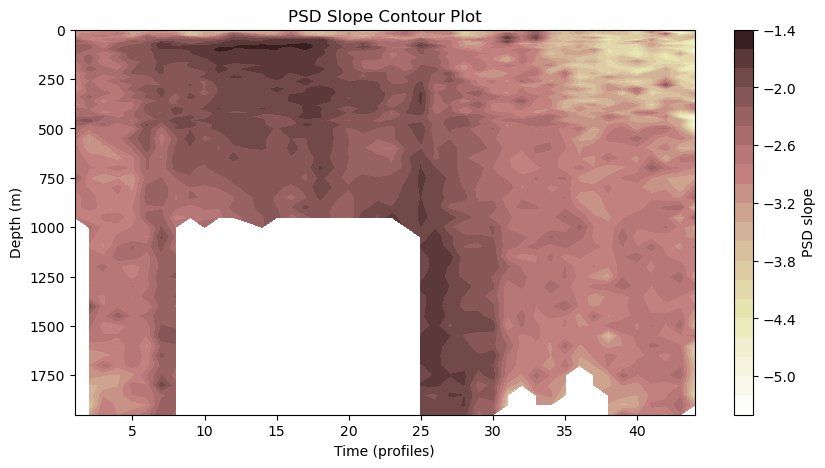

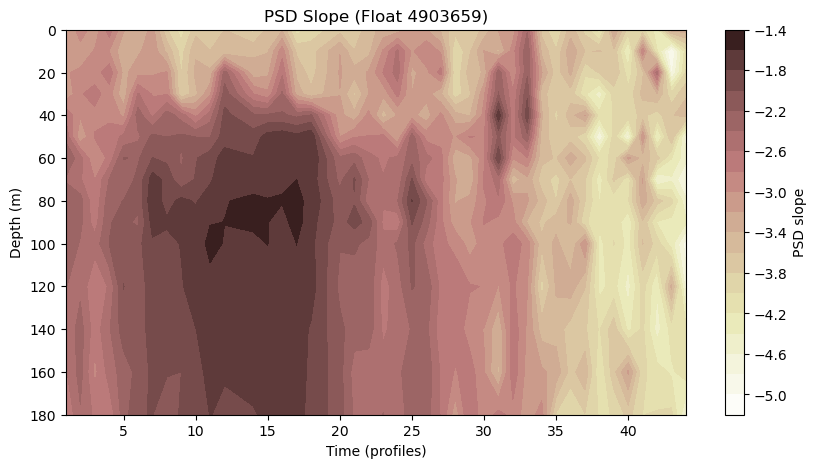

In [3]:
# BIOCARBON playing around
 

# # define parameters of particle size class, fluor, backscatter (maybe do a backscatter POC relationship curve conversion?), eventually turbulence


# input equations for particle dynamics - two size class approach?

# what float profiles match closest with the station locations?

# calculate PSD for each depth across size bins

def psd_slope(sizes, concentrations, use_cumulative=False):
    """
    Calculate PSD slope in log-log space.
    """

    import pandas as pd

    # Convert to pandas Series
    sizes = pd.Series(sizes).reset_index(drop=True)
    concentrations = pd.Series(concentrations).reset_index(drop=True)

    # Combine into DataFrame for easier handling
    df = pd.DataFrame({
        "sizes": sizes,
        "concentrations": concentrations
        })

    
    # Force numeric
    df["sizes"] = pd.to_numeric(df["sizes"], errors='coerce')
    df["concentrations"] = pd.to_numeric(df["concentrations"], errors='coerce')

    # Drop NaNs
    df = df.dropna()

    # Sort by size
    df = df.sort_values("sizes")

    # Normalize concentrations
    df["concentrations"] = df["concentrations"] / df["concentrations"].sum()

    # Optional cumulative
    if use_cumulative:
        df["concentrations"] = df["concentrations"].cumsum()

    # Remove invalid values for log
    df = df[(df["sizes"] > 0) & (df["concentrations"] > 0)]

    # Log transform (SAFE in pandas)
    df["log_sizes"] = df["sizes"].apply(lambda x: np.nan if x <= 0 else np.log10(x))
    df["log_conc"] = df["concentrations"].apply(lambda x: np.nan if x <= 0 else np.log10(x))


    df = df.dropna()

    # Linear regression using pandas (no np.polyfit)
    # slope = covariance(x,y) / variance(x)
    x = df["log_sizes"]
    y = df["log_conc"]

    slope = x.cov(y) / x.var()
    intercept = y.mean() - slope * x.mean()

    # Predicted values
    predicted = slope * x + intercept

    # R² calculation
    ss_res = ((y - predicted) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    r_squared = 1 - (ss_res / ss_tot)

    return {
        "slope": slope,
        "intercept": intercept,
        "r_squared": r_squared
    }

test_p1_f490 = pd.to_numeric(f490.p1.iloc[0, 1:], errors='coerce')
#print(psd_slope(size_classes, test_p1_f490))



# Find all .pX attributes
p_keys = [key for key in f490.__dict__.keys() if key.startswith("p")]

all_results = {}

for p_key in p_keys:
    p_df = getattr(f490, p_key)

    # Extract sizes (column headers, skip first column)
    sizes = pd.to_numeric(p_df.columns[1:], errors='coerce')

    slopes = []

    # Loop through ALL rows (depth bins)
    for row in range(p_df.shape[0]):
        concentrations = pd.to_numeric(p_df.iloc[row, 1:], errors='coerce')

        res = psd_slope(sizes, concentrations)
        slopes.append(res["slope"])

    # Store results for this dataset
    all_results[p_key] = slopes

# Create final DataFrame
slope_df = pd.DataFrame(all_results)


# just need to plot and have a look
fig, ax = plt.subplots(figsize=(10, 5))

# Convert columns ("p1", "p2", ...) → numbers
X = [int(col.replace("p", "")) for col in slope_df.columns]

# Depth (rows)
Y = pd.to_numeric(depth, errors="coerce").to_numpy()

# Meshgrid
X_grid, Y_grid = np.meshgrid(X, Y)

# Z values
Z = slope_df.to_numpy(dtype=float)

contour = plt.contourf(X_grid, Y_grid, Z, levels=20, cmap='pink_r')

plt.colorbar(contour, label="PSD slope")
plt.xlabel("Time (profiles)")
plt.ylabel("Depth (m)")
plt.title("PSD Slope Contour Plot")

# Invert depth axis (common in oceanography)
plt.gca().invert_yaxis()

plt.show()



# Plot from first 200 m 
fig, ax = plt.subplots(figsize=(10, 5))

# Convert columns ("p1", "p2", ...) → numbers
X = [int(col.replace("p", "")) for col in slope_df.columns]

# Depth (rows)
Y = pd.to_numeric(depth, errors="coerce").to_numpy()
Y_shallow = Y[0:15]

# Meshgrid
X_grid, Y_grid = np.meshgrid(X, Y_shallow)     # specify range that is length of Y and X

# Z values
Z = slope_df.iloc[:15, :].to_numpy(dtype=float)

contour = plt.contourf(X_grid, Y_grid, Z, levels=20, cmap='pink_r')

plt.plot()
plt.colorbar(contour, label="PSD slope")
plt.xlabel("Time (profiles)")
plt.ylabel("Depth (m)")
plt.title("PSD Slope (Float 4903659)")

# Invert depth axis
plt.gca().invert_yaxis()

plt.show()


**Smoluchowski's Population Balance Equation:**

$$
\frac{\partial n(m,t)}{\partial t}
= \frac{a}{2} \int_0^m B(m', m - m')\, n(m',t)\, n(m - m',t)\, dm'
- an(m,t)\,\int_0^\infty B(m, m')\, n(m',t)\, dm'
$$


[  1.22629815   1.29175273   1.37988478   1.50080255   1.66862511
   1.90789397   2.2524083    2.78430976   3.63278656   5.0835
   7.6906092   13.19713816  26.04953714  60.3402876  174.16445561]
[[4.90196078e-03 6.76054783e+01 3.48106046e+02 1.02010659e+03
  2.37160709e+03 4.88410755e+03 9.24160795e+03 1.68100083e+04
  2.94849086e+04 5.05521089e+04 8.42724091e+04 1.41134409e+05
  2.33478409e+05 3.79470410e+05 6.14048410e+05]
 [6.76054783e+01 3.90625000e-03 1.08904602e+02 5.62505287e+02
  1.63840594e+03 3.80250654e+03 7.72840708e+03 1.47456076e+04
  2.67289080e+04 4.69225083e+04 7.95664086e+04 1.35024409e+05
  2.25600409e+05 3.69408409e+05 6.01230409e+05]
 [3.48106046e+02 1.08904602e+02 3.10559006e-03 1.76403901e+02
  9.02504676e+02 2.62440541e+03 6.00250608e+03 1.23201067e+04
  2.34256072e+04 4.25104077e+04 7.37881081e+04 1.27464108e+05
  2.15796109e+05 3.56832109e+05 5.85156109e+05]
 [1.02010659e+03 5.62505287e+02 1.76403901e+02 2.46305419e-03
  2.80903333e+02 1.44000418e+03 4.1209049

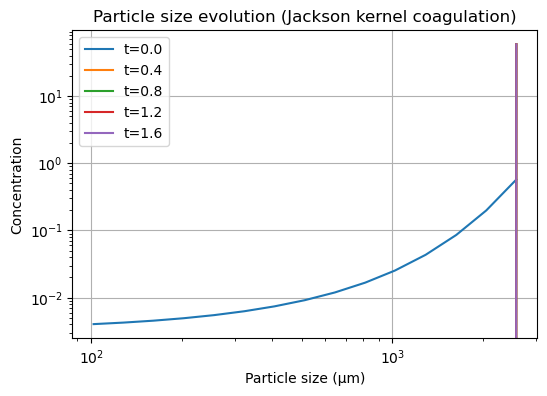

In [ ]:
## STEADY STATE MODEL      add sinking and particle injection to formula?

# define state variables?

# particle size classes


# IMPORTANT: the below is an AI-generated script for solving the Smoluchowski equation for particle size evolution, for learning only. No inclusion of stickiness, density or mass conservation 
# Please do not rely solely on this, only use it to learn and check against literature and supervisor and develop model


# ------------------------------
# 1. Define size bins
# ------------------------------
sizes = np.array([102,128,161,203,256,323,406,512,645,813,1020,1290,1630,2050,2580])             # specifies size classes, using 15
n = len(sizes)

# Initial concentration (example)                                                                # exponentially increasing size spectrum of initial particle concentrations (sample concs)
C = np.exp(sizes / 500)                                                                          # potentially here is where primary particles would go after calculating from backscatter?
print(C)                                                                                         # 
C = C / C.sum()  # normalise

# ------------------------------
# 2. Define Jackson-type kernel
# ------------------------------
def jackson_kernel(sizes):
    """
    #Example Jackson-style coagulation kernel:
    #combines differential settling + turbulent shear + Brownian # might not add Brownian but we'll see

    #You can customise this based on physics
    """
    K = np.zeros((n, n))                                                                         # creates a matrix of zeroes the same shape as the size classes, which will be filled with
                                                                                                 # the aggregation rates between different size classes
    for i in range(n):                                                                           # then the collision rate for every pair of sizes is computed and put into the matrix?
        for j in range(n):
            # Example components
            brownian = 1 / (sizes[i] + sizes[j])
            shear = abs(sizes[i] - sizes[j]) / (sizes[i] + sizes[j])                             # don't know if this is correct to be dependent on size difference, would have thought it's based on turbulence energy?
            differential_settling = (sizes[i]**2 - sizes[j]**2)**2 / (sizes[i] + sizes[j])**2

            # Combine terms (weights adjustable)
            K[i, j] = brownian + 0.01 * shear + 0.1 * differential_settling

    return K

K = jackson_kernel(sizes)
print(K)

# ------------------------------
# 3. Time stepping
# ------------------------------
dt = 0.01                                                                                        # presumably could amend this to be over depth step initially for steady state model?
t_end = 2.0
n_steps = int(t_end / dt)

C_history = [C.copy()]                                                                           # stores initial concentration distribution of particles

for step in range(n_steps):
    dC = np.zeros_like(C)

    # Gain term
    for k in range(n):
        gain = 0
        for i in range(n):
            for j in range(n):
                if min(i+j, n-1) == k:  # bin mapping                                            # as size i + size j may not necessarily equal size k so there is some sorting into that bin?
                    gain += K[i, j] * C[i] * C[j]
        dC[k] += 0.5 * gain                                                                      # prevents double counting of particles, e.g. i+j and j+i are the same event

    # Loss term
    for k in range(n):
        loss = 0
        for j in range(n):
            loss += K[k, j] * C[j]
        dC[k] -= C[k] * loss

    # Update concentrations
    C = C + dt * dC
    C = np.maximum(C, 0)  # prevent negatives

    C_history.append(C.copy())

C_history = np.array(C_history)
print(np.shape(C_history))                                                                       # produces 200 timesteps of concentration for each size class

# ------------------------------
# 4. Plot results
# ------------------------------
plt.figure(figsize=(6, 4))

for i in range(0, n_steps, int(n_steps/5)):
    plt.plot(sizes, C_history[i], label=f"t={i*dt:.1f}")

plt.xlabel("Particle size (µm)")
plt.ylabel("Concentration")
plt.title("Particle size evolution (Jackson kernel coagulation)")
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.grid()

plt.show()



# needs to have a diagnostic figure similar to the cross-sectional area plot below
# and likely one for checking mass conservation too, i.e. sum of all particle masses should remain constant


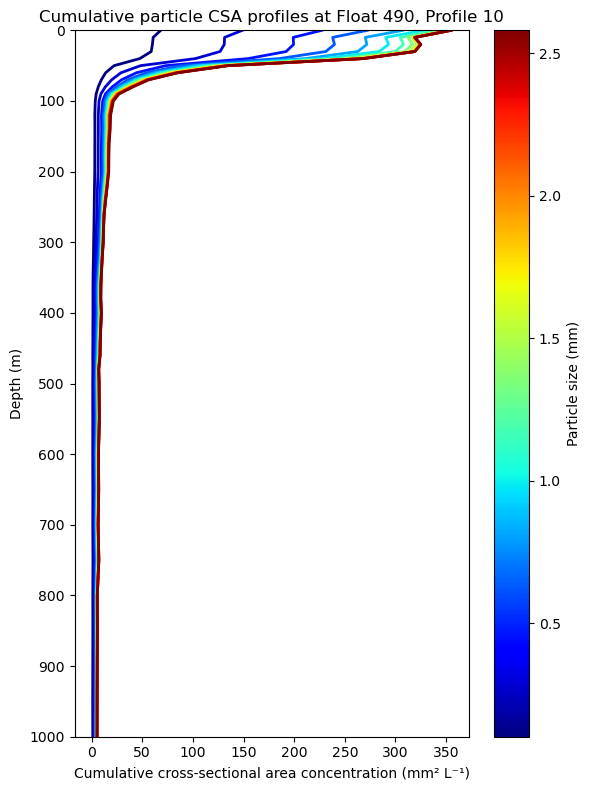

In [24]:
## OBSERVATIONAL DATA DEPTH PROFILE (DIAGNOSTIC FIGURE) 

# pick profile that will be used as a diagnostic, maybe close to super station or something
# would need to calculate cross-sectional area of particles (method in notebook) for each size class
# then expand that over depth

mid_size = pd.read_excel("UVP_Float_Data.xlsx", sheet_name="UVP_Float_Data").iloc[3:18, 16]     # (size_mid_um)
mid_size.drop_duplicates()
mid_size = mid_size.to_numpy(dtype=float)
mid_size[-1] = 2580

# Choose which float and profile to investigate
UVP6_float = 490
number = 10
profile = f490.p10  # here you can change the float profile, could probably tidy this up more so that when you write your variable name it updates UVP6_float and number automatically but not a good use of time

# Apply mid-size scaling
# shape = (n_sizes, n_depth)
concs = np.array([profile[s] for s in sizes], dtype=float)
cross_sectional_area = (concs * mid_size[:, None]) / 1000



# Plotting Cumulative stack

fig, ax = plt.subplots(figsize=(6,8))

# cumulative sum across size bins
cumulative = np.cumsum(cross_sectional_area, axis=0)

# create a colour gradient
cmap = plt.cm.jet   # you can change this (plasma, turbo, etc.)
colors = cmap(np.linspace(0, 1, len(sizes/1000)))

# plot each cumulative boundary as a line
for i, s in enumerate(sizes):
    ax.plot(cumulative[i], depth,
            color=colors[i],
            linewidth=2)

ax.set_xlabel("Cumulative cross-sectional area concentration (mm² L⁻¹)")
ax.set_ylabel("Depth (m)")
ax.set_ylim(0, 1000)
ax.set_yticks(np.linspace(0, 1000, 11))
ax.set_title(f"Cumulative particle CSA profiles at Float {UVP6_float}, Profile {number}")

# Colourbar
norm = plt.Normalize(vmin=min(sizes/1000), vmax=max(sizes/1000))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Particle size (mm)")

# Add Mixed Layer Depth? # mld = point at which temp at 10 m according to de Boyer Montegut et al, 2004

ax.invert_yaxis()

plt.tight_layout()
plt.show()